In [1]:
from utils.utils import *
from oasis.functions import deconvolve
import matplotlib.pyplot as plt

Load data

In [2]:
data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


Apply spike train inference and add it to the original data

In [3]:
def infer_spikes_oasis(session, fs):
    dff = session["dff"]
    n_cells, n_time = dff.shape
    spikes = np.zeros_like(dff)
    calcium = np.zeros_like(dff)
    for i in range(n_cells):
        c, s, b, g, lam = deconvolve(dff[i], tau_d=0.1, framerate=fs)
        spikes[i] = s
        calcium[i] = c
    return spikes, calcium

In [4]:
for name, session in data["sessions"].items():
    fs = 1.0 / np.median(np.diff(session["t"]))
    spikes, calcium = infer_spikes_oasis(session, fs)
    session["spikes"] = spikes
    session["calcium_fit"] = calcium

Save the data

In [5]:
save_data(data, "data_with_spikes")

In [5]:
data = load_saved_data("data_with_spikes")

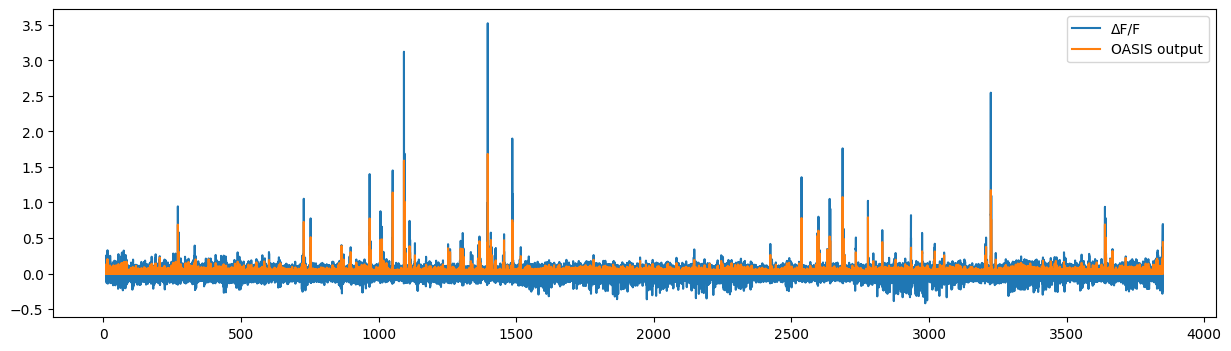

In [6]:
plt.figure(figsize=(15, 4))

plt.plot(session["t"], session["dff"][0], label="ΔF/F")
plt.plot(session["t"], session["spikes"][0], label="OASIS output")

plt.legend()